# EDA — Master of Telegram Ads (Track 2): VIEWS forecasting

This notebook is **project-facing**: it documents data quality, distributions, leakage risks, and what features/models are likely to work.

**Task:** predict `VIEWS` using only: `CPM`, `CHANNEL_NAME`, `DATE`.

> Note: `AllData.csv` includes extra columns (`AD_ID`, `CLICKS`, `ACTIONS`) — useful for analysis, but **not allowed** as inference features.

In [41]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
# Load data
path = "data/AllData.csv"
df = pd.read_csv(path) # loading data
df.head() # viewing first 5 rows

,AD_ID,CPM,VIEWS,CLICKS,ACTIONS,CHANNEL_NAME,DATE
0,3652,1.2,52,0,0,tanya_in_france,2024-10-02
1,3653,1.2,54,2,0,relocator_cc,2024-10-02
2,3654,1.2,15,1,0,teleportazia,2024-10-02
3,3655,1.5,85,2,1,spetsialist_visa_support,2024-10-02
4,3656,19.4,688,21,3,pitkvch_news,2024-10-02


In [43]:
df.columns = df.columns.str.strip()

## 2) High-level overview

In [44]:
df.shape # Information about shape of Data Frame 

(142609, 7)

In [45]:
df.dtypes # CHANNEL_NAME, DATE are object types;
# All others are float or int

AD_ID             int64
CPM             float64
VIEWS             int64
CLICKS            int64
ACTIONS           int64
CHANNEL_NAME     object
DATE             object
dtype: object

In [46]:
df.isna().sum() # Data for training does not have empty cells

AD_ID           0
CPM             0
VIEWS           0
CLICKS          0
ACTIONS         0
CHANNEL_NAME    0
DATE            0
dtype: int64

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142609 entries, 0 to 142608
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   AD_ID         142609 non-null  int64  
 1   CPM           142609 non-null  float64
 2   VIEWS         142609 non-null  int64  
 3   CLICKS        142609 non-null  int64  
 4   ACTIONS       142609 non-null  int64  
 5   CHANNEL_NAME  142609 non-null  object 
 6   DATE          142609 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 7.6+ MB


## 3) Date parsing and coverage

In [48]:
df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")
df.dtypes # Converting from object to data types

AD_ID                    int64
CPM                    float64
VIEWS                    int64
CLICKS                   int64
ACTIONS                  int64
CHANNEL_NAME            object
DATE            datetime64[ns]
dtype: object

In [49]:
date_min, date_max = df["DATE"].min(), df["DATE"].max()
n_days = df["DATE"].nunique()

date_min, date_max, n_days

(Timestamp('2024-10-02 00:00:00'), Timestamp('2025-12-17 00:00:00'), 430)

## 4) Descriptive statistics and tails

In [54]:
num_cols = ["CPM", "VIEWS", "CLICKS", "ACTIONS"]
df[num_cols].describe(percentiles=[0.5, 0.9, 0.95, 0.99])

,CPM,VIEWS,CLICKS,ACTIONS
count,142609.000000,1.426090e+05,142609.000000,142609.000000
mean,8.994971,9.998400e+02,13.245714,4.478245
std,29.404112,7.260922e+03,211.894919,159.825803
min,1.000000,0.000000e+00,0.000000,0.000000
50%,3.530000,2.550000e+02,1.000000,0.000000
90%,19.900000,1.642000e+03,16.000000,3.000000
95%,29.700000,3.196600e+03,35.000000,8.000000
99%,63.000000,1.199692e+04,183.000000,49.000000
max,999.910000,1.136470e+06,48513.000000,37978.000000


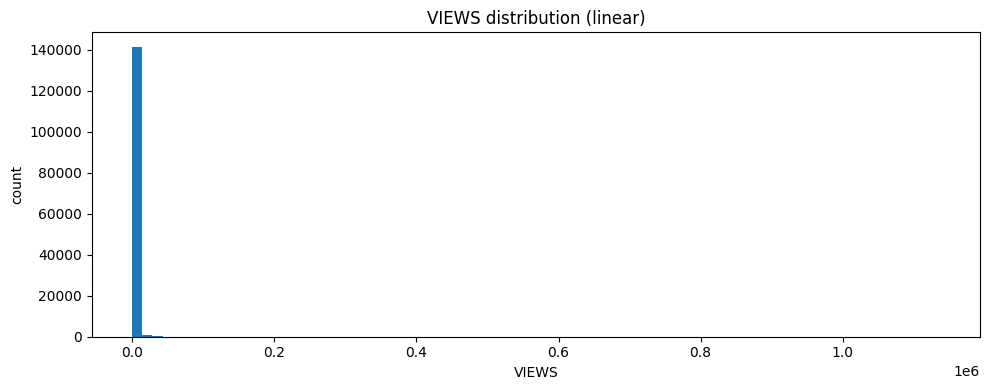

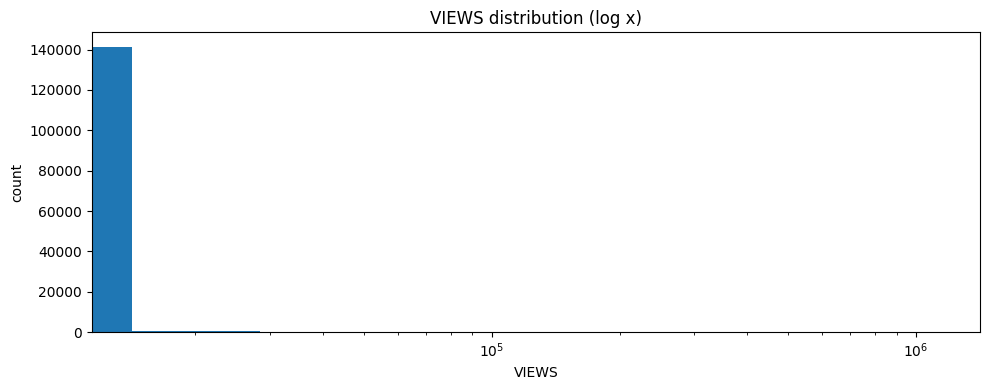

In [51]:
# Helper: histogram with optional log scaling
def plot_hist(series, title, bins=60, logx=False, logy=False):
    s = series.dropna().astype(float)
    plt.figure(figsize=(10,4))
    plt.hist(s, bins=bins)
    plt.title(title)
    plt.xlabel(series.name)
    plt.ylabel("count")
    if logx:
        plt.xscale("log")
    if logy:
        plt.yscale("log")
    plt.tight_layout()
    plt.show()

plot_hist(df["VIEWS"], "VIEWS distribution (linear)", bins=80)
plot_hist(df["VIEWS"], "VIEWS distribution (log x)", bins=80, logx=True)